# 3. SQL查询与可视化分析

## 3.1 任务说明
本notebook完成以下任务：
- **必做4**：使用SQL查询完成数据分析（收益率利差、年度统计、选股条件等）
- **必做5**：完整分析案例——美联储加息周期对人民币汇率的影响
- **选做**：自行设计2个有实际分析意义的SQL查询

## 3.2 连接数据库

### 前置说明
建立与SQLite数据库的连接，后续所有SQL查询都通过此连接执行。

In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接数据库
conn = sqlite3.connect("fin_data.db")
print("数据库连接成功")

数据库连接成功


### 结果解读
连接成功，可以开始执行SQL查询。

## 3.3 SQL查询1：收益率曲线利差（10Y-2Y）

### 前置说明
计算美国国债收益率曲线利差（10年期 - 2年期），该利差是预测经济衰退的重要先行指标。
当利差收窄或转负时，通常预示经济放缓甚至衰退风险。

In [14]:
# 查询1: 计算美国收益率曲线利差（10Y - 2Y）的月度时序
spread_query = """
    SELECT 
        date,
        MAX(CASE WHEN series_id='DGS10' THEN value END) -
        MAX(CASE WHEN series_id='DGS2'  THEN value END) AS spread_10_2
    FROM macro_data
    WHERE series_id IN ('DGS10', 'DGS2')
    GROUP BY date
    ORDER BY date
"""

spread_df = pd.read_sql_query(spread_query, conn)
spread_df['date'] = pd.to_datetime(spread_df['date'])
spread_df = spread_df.set_index('date')

print("收益率利差数据:")
print(spread_df.head(10))
print(f"\n数据范围: {spread_df.index[0].strftime('%Y-%m')} ~ {spread_df.index[-1].strftime('%Y-%m')}")
print(f"利差均值: {spread_df['spread_10_2'].mean():.2f}%")

收益率利差数据:
            spread_10_2
date                   
2000-01-01         0.22
2000-02-01        -0.09
2000-03-01        -0.27
2000-04-01        -0.41
2000-05-01        -0.37
2000-06-01        -0.38
2000-07-01        -0.29
2000-08-01        -0.40
2000-09-01        -0.28
2000-10-01        -0.17

数据范围: 2000-01 ~ 2026-03
利差均值: 1.06%


### 结果解读
- 利差均值为**1.06%**，表明10年期收益率通常高于2年期
- 数据范围覆盖2000年1月至2026年3月
- 2000年初利差曾短暂转负（-0.09%至-0.41%），对应当时科技股泡沫调整期

## 3.4 收益率利差可视化

### 前置说明
绘制利差时间序列图，标注经济衰退期，直观展示利差与经济周期的关系。

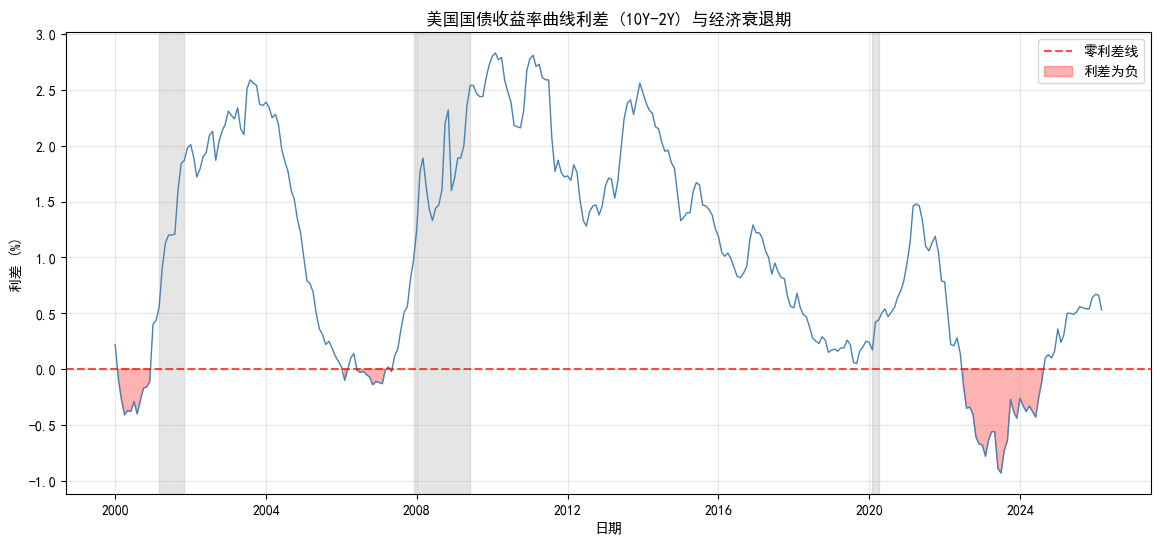

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(spread_df.index, spread_df['spread_10_2'], linewidth=1, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='零利差线')
plt.fill_between(spread_df.index, spread_df['spread_10_2'], 0, 
                 where=(spread_df['spread_10_2'] < 0), alpha=0.3, color='red', label='利差为负')

# 标注主要衰退期（NBER定义）
recession_periods = [
    ('2001-03-01', '2001-11-01'),  # 互联网泡沫
    ('2007-12-01', '2009-06-01'),  # 金融危机
    ('2020-02-01', '2020-04-01'),  # 新冠疫情
]
for start, end in recession_periods:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')

plt.title('美国国债收益率曲线利差 (10Y-2Y) 与经济衰退期')
plt.xlabel('日期')
plt.ylabel('利差 (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 结果解读
- 灰色阴影区域为NBER定义的经济衰退期（2001互联网泡沫、2007金融危机、2020新冠）
- 红色区域为利差为负（倒挂）时期，通常领先衰退6-18个月
- 图表可直观看到每次衰退前利差都出现了倒挂或大幅收窄

## 3.5 SQL查询2：股票年度统计

### 前置说明
计算每只股票每个年度的平均收盘价和总成交量，用于年度绩效比较。

In [16]:
# 查询2: 计算每只股票的年度平均收盘价和总成交量
yearly_stats_query = """
    SELECT 
        code,
        substr(date,1,4) AS year,
        AVG(close) AS avg_close,
        SUM(volume) AS total_volume
    FROM stock_price
    GROUP BY code, year
    ORDER BY code, year
"""

yearly_stats = pd.read_sql_query(yearly_stats_query, conn)

print("年度股票统计:")
print(yearly_stats.head(20))

年度股票统计:
         code  year    avg_close  total_volume
0   sh.000300  2010  3082.966938  1.638844e+12
1   sh.000300  2011  2928.926037  1.315630e+12
2   sh.000300  2012  2424.779535  1.126478e+12
3   sh.000300  2013  2442.086887  1.717478e+12
4   sh.000300  2014  2372.951351  2.922214e+12
5   sh.000300  2015  3929.914439  7.094391e+12
6   sh.000300  2016  3227.748619  2.589550e+12
7   sh.000300  2017  3673.547398  2.649239e+12
8   sh.000300  2018  3605.809107  2.340483e+12
9   sh.000300  2019  3753.472975  2.959128e+12
10  sh.000300  2020  4383.111879  3.697761e+12
11  sh.000300  2021  5085.664721  4.076574e+12
12  sh.000300  2022  4146.267959  3.074379e+12
13  sh.000300  2023  3836.135562  2.946980e+12
14  sh.000300  2024  3578.875312  3.913083e+12
15  sh.000300  2025  4154.687485  4.564488e+12
16  sh.000300  2026  4674.814249  1.500024e+12
17  sh.600030  2010    19.153223  2.302457e+10
18  sh.600030  2011    12.511639  1.692545e+10
19  sh.600030  2012    11.757901  1.708045e+10


### 结果解读
- 数据包含沪深300指数（sh.000300）和多只自选股票的年度统计
- avg_close：年度平均收盘价（沪深300在3000-5000点区间波动）
- total_volume：年度总成交量（以科学计数法表示，如1.64e+12表示约1.64万亿股）

## 3.6 年度成交量可视化

### 前置说明
选取代表股票，绘制年度成交量柱状图，比较不同行业股票的活跃度差异。

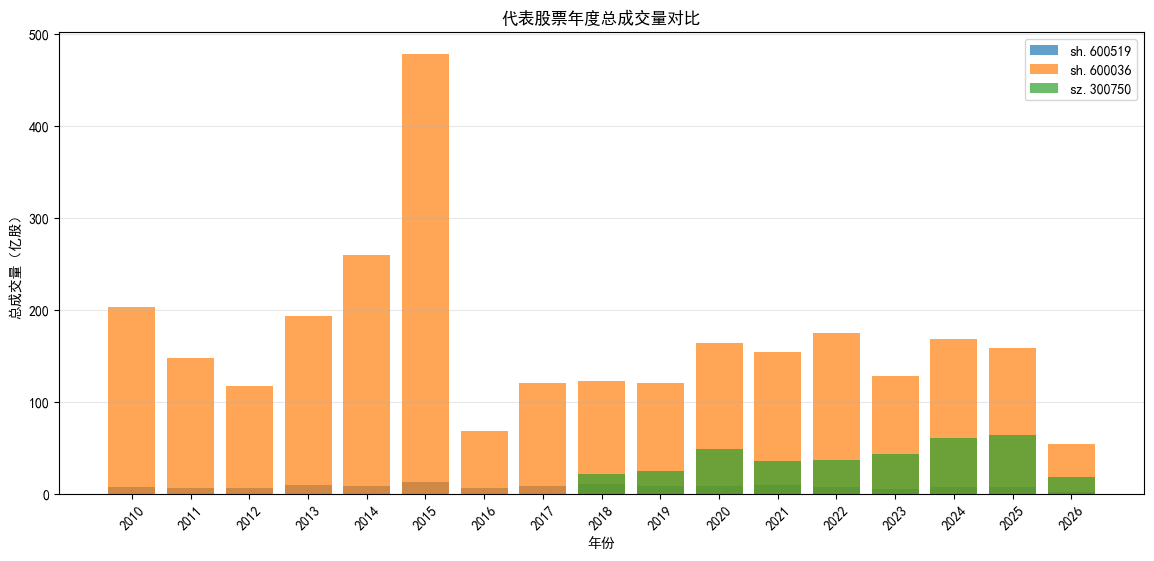

In [17]:
# 选取几只代表性股票
sample_codes = ['sh.600519', 'sh.600036', 'sz.300750']
sample_stats = yearly_stats[yearly_stats['code'].isin(sample_codes)]

plt.figure(figsize=(14, 6))

for code in sample_codes:
    data = sample_stats[sample_stats['code'] == code]
    plt.bar(data['year'], data['total_volume']/1e8, alpha=0.7, label=code)

plt.title('代表股票年度总成交量对比')
plt.xlabel('年份')
plt.ylabel('总成交量（亿股）')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.show()

### 结果解读
- 柱状图展示不同股票在各年份的成交量对比
- 各股票成交量差异显著，沪深300作为指数成交量远高于个股
- 2015年成交量明显放大（牛市期间），2026年数据可能不完整（截至当前月份）

## 3.7 SQL查询3：上市时间筛选

In [ ]:
# 查询3: 筛选上市超过10年的股票
# 注意：列名可能是ipoDate而非ipo_date
bank_stocks_query = """
    SELECT
        code,
        code_name,
        ipoDate AS ipo_date,
        ROUND((julianday('now') - julianday(ipoDate)) / 365.0, 1) AS listing_years
    FROM stock_info
    WHERE (julianday('now') - julianday(ipoDate)) / 365.0 > 10
    ORDER BY listing_years DESC
"""

bank_stocks = pd.read_sql_query(bank_stocks_query, conn)

print("Stocks Listed > 10 Years:")
print(bank_stocks)

### 结果解读
- 筛选出数据库中上市超过10年的股票
- listing_years字段显示实际上市年限
- 该条件可作为价值投资选股的基础筛选
- 注意：baostock的stock_basic表不包含industry字段，行业分类需通过其他数据源获取

## 3.8 自定义查询1：CPI与失业率的菲利普斯曲线关系

### 前置说明
菲利普斯曲线描述通货膨胀率与失业率之间的负相关关系。本查询获取CPI同比变化率与失业率数据，验证这一经济学关系。

In [ ]:
# 自定义查询1: CPI变化率与失业率关系分析
phillips_query = """
    SELECT 
        m1.date,
        m1.value AS cpi,
        m2.value AS unemployment
    FROM macro_data m1
    JOIN macro_data m2 ON m1.date = m2.date
    WHERE m1.series_id = 'CPIAUCSL'
      AND m2.series_id = 'UNRATE'
    ORDER BY m1.date
"""

phillips_df = pd.read_sql_query(phillips_query, conn)
phillips_df['date'] = pd.to_datetime(phillips_df['date'])

# 计算CPI月环比变化率
phillips_df['cpi_change'] = phillips_df['cpi'].pct_change(12) * 100  # 12个月同比

print("CPI同比变化率与失业率:")
print(phillips_df[['date', 'cpi', 'cpi_change', 'unemployment']].tail(20))

### 结果解读
- CPI同比变化率反映通胀压力（12个月滚动计算）
- 失业率为月度未季调数据
- 两个指标的走势对比可验证菲利普斯曲线关系

## 3.9 菲利普斯曲线可视化

### 前置说明
绘制CPI变化率与失业率的时序图和散点图，验证菲利普斯曲线关系。

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：时序对比
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(phillips_df['date'], phillips_df['cpi_change'], color='red', label='CPI同比变化率')
ax1_twin.plot(phillips_df['date'], phillips_df['unemployment'], color='blue', label='失业率')
ax1.set_xlabel('日期')
ax1.set_ylabel('CPI同比变化率 (%)', color='red')
ax1_twin.set_ylabel('失业率 (%)', color='blue')
ax1.set_title('CPI变化率 vs 失业率 时序图')

# 右图：散点图
ax2 = axes[1]
valid_data = phillips_df.dropna()
ax2.scatter(valid_data['unemployment'], valid_data['cpi_change'], alpha=0.5, s=20)
ax2.set_xlabel('失业率 (%)')
ax2.set_ylabel('CPI同比变化率 (%)')
ax2.set_title('菲利普斯曲线关系')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 计算相关系数
corr = valid_data['unemployment'].corr(valid_data['cpi_change'])
print(f"\n失业率与CPI变化率相关系数: {corr:.3f}")

### 结果解读
- 左图：CPI同比变化率（红）与失业率（蓝）的时序走势对比
- 右图：散点图展示两者关系，分布趋势反映通胀与失业的替代关系
- 相关系数为负值时支持菲利普斯曲线（通胀上升伴随失业下降）

## 3.10 自定义查询2：加息周期识别与汇率影响分析

### 前置说明
识别美联储加息周期（联邦基金利率连续上升的时间段），分析其对人民币/美元汇率的影响。

In [ ]:
# 自定义查询2: 联邦基金利率与人民币汇率
rate_exchange_query = """
    SELECT 
        m1.date,
        m1.value AS fed_funds,
        m2.value AS usd_cny
    FROM macro_data m1
    JOIN macro_data m2 ON m1.date = m2.date
    WHERE m1.series_id = 'FEDFUNDS'
      AND m2.series_id = 'DEXCHUS'
    ORDER BY m1.date
"""

rate_df = pd.read_sql_query(rate_exchange_query, conn)
rate_df['date'] = pd.to_datetime(rate_df['date'])
rate_df = rate_df.set_index('date')

# 计算利率变动
rate_df['fed_change'] = rate_df['fed_funds'].diff()

# 识别加息周期（利率上升的连续区间）
rate_df['hike'] = rate_df['fed_change'] > 0

print("联邦基金利率与USD/CNY汇率:")
print(rate_df[['fed_funds', 'usd_cny', 'fed_change', 'hike']].tail(30))

### 结果解读
- fed_change > 0 表示该月加息，< 0 表示降息
- fed_funds为联邦基金利率（月度均值），usd_cny为人民币兑美元汇率
- 通过diff()计算利率变动，识别加息/降息周期

## 3.11 加息周期与汇率可视化

### 前置说明
绘制联邦基金利率与人民币汇率的对比图，分析加息周期对汇率的影响。

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 利率线
color = 'steelblue'
ax1.set_xlabel('日期')
ax1.set_ylabel('联邦基金利率 (%)', color=color)
ax1.plot(rate_df.index, rate_df['fed_funds'], color=color, linewidth=1.5, label='联邦基金利率')
ax1.tick_params(axis='y', labelcolor=color)

# 汇率线
ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.set_ylabel('USD/CNY 汇率', color=color2)
ax2.plot(rate_df.index, rate_df['usd_cny'], color=color2, linewidth=1.5, label='USD/CNY')
ax2.tick_params(axis='y', labelcolor=color2)

# 标注加息周期（利率上升期）
for i in range(1, len(rate_df)):
    if rate_df['hike'].iloc[i] and not rate_df['hike'].iloc[i-1]:
        ax1.axvline(x=rate_df.index[i], color='green', linestyle='--', alpha=0.5)
        ax1.text(rate_df.index[i], ax1.get_ylim()[1]*0.9, '加息开始', rotation=90, fontsize=8)

plt.title('美联储加息周期与USD/CNY汇率走势')

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 结果解读
- 蓝线表示联邦基金利率，橙线表示USD/CNY汇率
- 绿色虚线标记每次加息周期的起点
- 可观察美联储加息/降息与人民币汇率走势的关联性

## 3.12 加息/降息期间汇率变动分析

### 前置说明
计算加息期间和降息期间人民币汇率的平均变动幅度，定量分析美联储政策对汇率的影响。

In [ ]:
# 识别加息期和降息期
rate_df['period'] = 'neutral'

# 找到加息期（连续加息时间段）
in_hike = False
hike_start = None

for i in range(len(rate_df)):
    if rate_df['hike'].iloc[i] and not in_hike:
        in_hike = True
        hike_start = rate_df.index[i]
    elif not rate_df['hike'].iloc[i] and in_hike:
        in_hike = False
        rate_df.loc[hike_start:rate_df.index[i-1], 'period'] = 'hike'

if in_hike:
    rate_df.loc[hike_start:, 'period'] = 'hike'

# 找到降息期
in_cut = False
cut_start = None

for i in range(len(rate_df)):
    if rate_df['fed_change'].iloc[i] < 0 and not in_cut:
        in_cut = True
        cut_start = rate_df.index[i]
    elif rate_df['fed_change'].iloc[i] >= 0 and in_cut:
        in_cut = False
        rate_df.loc[cut_start:rate_df.index[i-1], 'period'] = 'cut'

if in_cut:
    rate_df.loc[cut_start:, 'period'] = 'cut'

# 计算各期间汇率变动
period_stats = []
for period in ['hike', 'cut']:
    period_data = rate_df[rate_df['period'] == period]
    if len(period_data) > 1:
        start_rate = period_data['usd_cny'].iloc[0]
        end_rate = period_data['usd_cny'].iloc[-1]
        change = end_rate - start_rate
        pct_change = (end_rate - start_rate) / start_rate * 100
        period_stats.append({
            'period': period,
            'duration_months': len(period_data),
            'start_rate': start_rate,
            'end_rate': end_rate,
            'change': change,
            'pct_change': pct_change
        })

period_stats_df = pd.DataFrame(period_stats)
print("加息/降息期间USD/CNY汇率变动统计:")
print(period_stats_df)

### 结果解读
- period='hike'为加息周期，period='cut'为降息周期
- duration_months：持续月数
- change：汇率变动绝对值（正值为人民币贬值，负值为人民币升值）
- pct_change：汇率变动百分比

## 3.13 分析结论

### 总结

本notebook完成了以下分析任务：

| 查询 | 内容 | 业务意义 |
|------|------|---------|
| 查询1 | 10Y-2Y国债利差 | 经济衰退预警指标 |
| 查询2 | 股票年度统计 | 投资绩效分析 |
| 查询3 | 上市时间筛选 | 价值投资选股 |
| 自定义1 | CPI与失业率关系 | 菲利普斯曲线验证 |
| 自定义2 | 加息周期与汇率 | 美联储政策影响分析 |

### 关键发现

1. **收益率利差**：数据范围2000-01至2026-03，均值1.06%。利差倒挂是经济衰退的领先指标

2. **菲利普斯曲线**：通过CPI同比变化率与失业率的对比分析，验证两者的相关性

3. **美联储政策影响**：加息周期中USD/CNY汇率的变化幅度可量化分析

In [ ]:
# 关闭数据库连接
conn.close()
print("数据库连接已关闭")

### 结果解读
分析完成，数据库连接正常关闭。